In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as pt
from sklearn.metrics import classification_report, accuracy_score

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [3]:
print("Training Size : ", X_train.shape)
print("Testing Size : ", X_test.shape)

Training Size :  (60000, 28, 28)
Testing Size :  (10000, 28, 28)


In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784, )),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [8]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8262 - loss: 0.4852 - val_accuracy: 0.8367 - val_loss: 0.4466
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8665 - loss: 0.3632 - val_accuracy: 0.8584 - val_loss: 0.3983
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8794 - loss: 0.3285 - val_accuracy: 0.8670 - val_loss: 0.3686
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8873 - loss: 0.3062 - val_accuracy: 0.8686 - val_loss: 0.3630
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8925 - loss: 0.2873 - val_accuracy: 0.8752 - val_loss: 0.3471
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8968 - loss: 0.2758 - val_accuracy: 0.8759 - val_loss: 0.3447
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9020 - loss: 0.2645 - val_accuracy: 0.8785 - val_loss: 0.3400
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9054 - loss: 0.2527 - 

In [9]:
prediction = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  


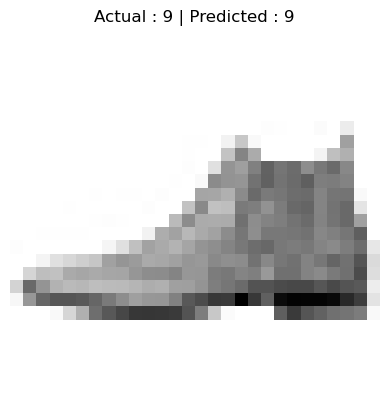

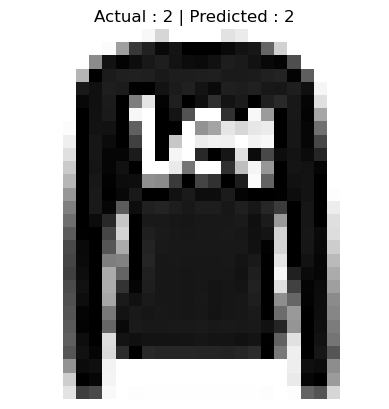

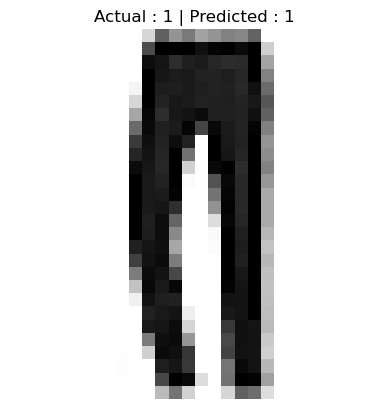

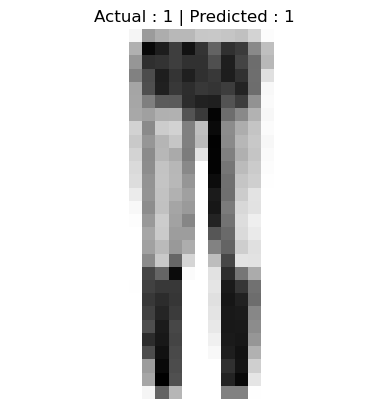

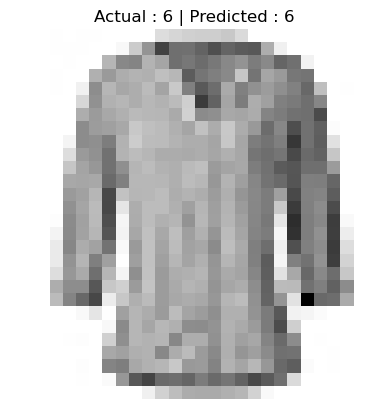

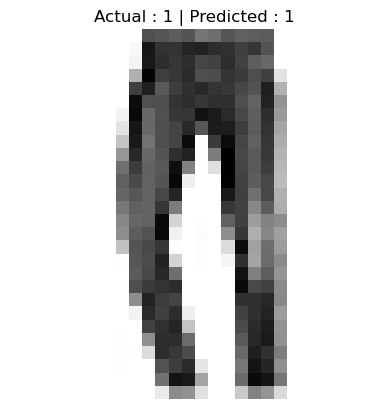

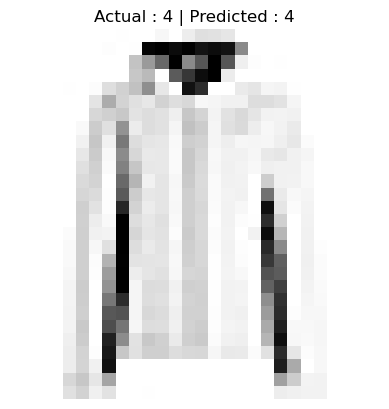

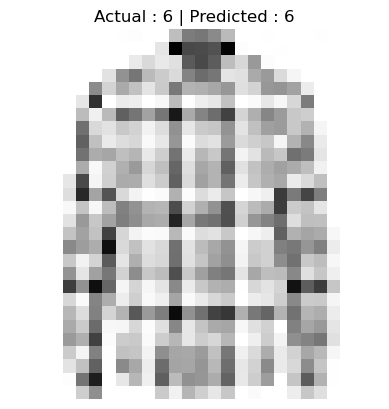

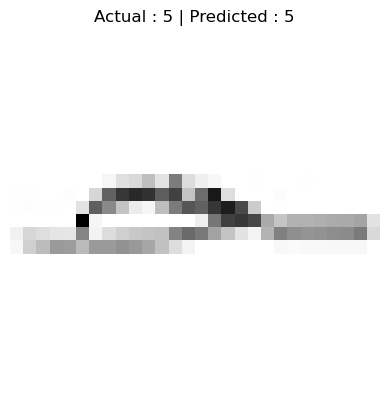

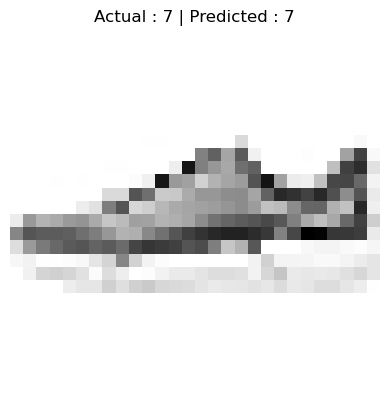

In [10]:
for i in range(10):
    pt.imshow(X_test[i].reshape(28, 28), cmap='Grays')
    pt.title(f"Actual : {y_test[i]} | Predicted : {np.argmax(prediction[i])}")
    pt.axis('off')
    pt.show()

In [11]:
print(classification_report(y_test, (np.argmax(prediction, axis=1))))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.83      0.71      0.77      1000
           3       0.82      0.94      0.88      1000
           4       0.74      0.85      0.79      1000
           5       0.98      0.94      0.96      1000
           6       0.74      0.66      0.70      1000
           7       0.92      0.97      0.95      1000
           8       0.96      0.98      0.97      1000
           9       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [12]:
print("Accuracy : ",100 * accuracy_score(y_test, (np.argmax(prediction, axis=1))))

Accuracy :  87.88
